In [25]:
import os
import glob

import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

BASE_DIR = os.path.abspath('..')  # if notebook resides in /notebooks
DATA_DIR = os.path.join(BASE_DIR, 'data')
REC_DIR = os.path.join(DATA_DIR, 'receipts_raw')

print("DATA_DIR:", DATA_DIR)
print("REC_DIR:", REC_DIR)

DATA_DIR: d:\HND NIBM\img processing & computer vision project\kyc-robustness\data
REC_DIR: d:\HND NIBM\img processing & computer vision project\kyc-robustness\data\receipts_raw


In [26]:
def show_image(title, img, cmap=None, size=(6, 6)):
    plt.figure(figsize=size)
    if cmap is None:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [27]:
rec_paths = glob.glob(os.path.join(REC_DIR, '*'))
print("Number of receipt images:", len(rec_paths))
rec_paths[:5]

Number of receipt images: 163


['d:\\HND NIBM\\img processing & computer vision project\\kyc-robustness\\data\\receipts_raw\\000.jpg',
 'd:\\HND NIBM\\img processing & computer vision project\\kyc-robustness\\data\\receipts_raw\\001.jpg',
 'd:\\HND NIBM\\img processing & computer vision project\\kyc-robustness\\data\\receipts_raw\\002.jpg',
 'd:\\HND NIBM\\img processing & computer vision project\\kyc-robustness\\data\\receipts_raw\\003.jpg',
 'd:\\HND NIBM\\img processing & computer vision project\\kyc-robustness\\data\\receipts_raw\\004.jpg']

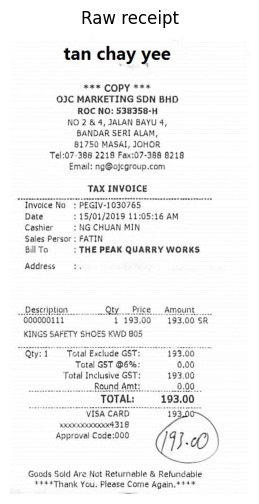

In [28]:
rec_img = cv2.imread(rec_paths[0])
show_image("Raw receipt", rec_img)

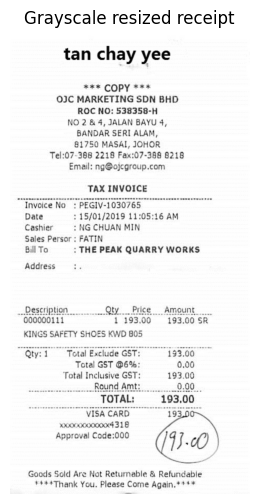

In [29]:
rec_gray = cv2.cvtColor(rec_img, cv2.COLOR_BGR2GRAY)

h, w = rec_gray.shape
new_w = 800
scale = new_w / w
new_h = int(h * scale)
rec_gray_resized = cv2.resize(rec_gray, (new_w, new_h))

show_image("Grayscale resized receipt", rec_gray_resized, cmap='gray')

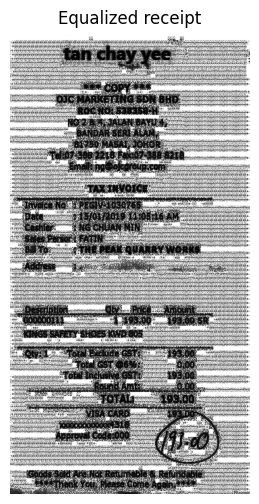

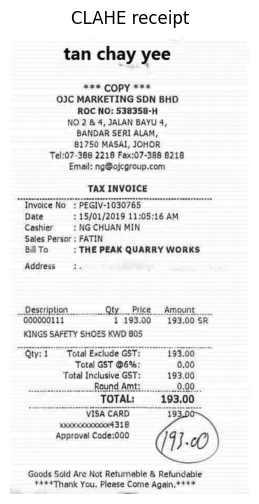

In [30]:
# Histogram equalization
rec_eq = cv2.equalizeHist(rec_gray_resized)
show_image("Equalized receipt", rec_eq, cmap='gray')

# OR CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
rec_clahe = clahe.apply(rec_gray_resized)
show_image("CLAHE receipt", rec_clahe, cmap='gray')

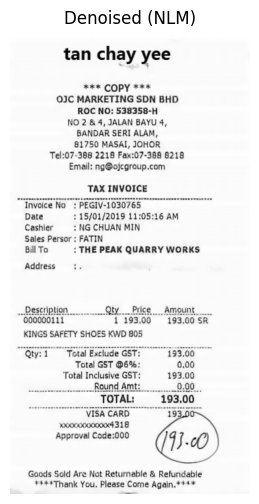

In [31]:
rec_denoised = cv2.fastNlMeansDenoising(rec_clahe, h=10)
show_image("Denoised (NLM)", rec_denoised, cmap='gray')

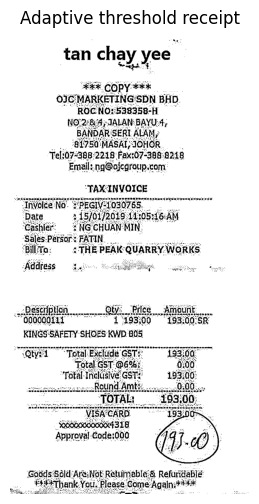

In [32]:
rec_adaptive = cv2.adaptiveThreshold(
    rec_denoised, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=11,
    C=2
)
show_image("Adaptive threshold receipt", rec_adaptive, cmap='gray')

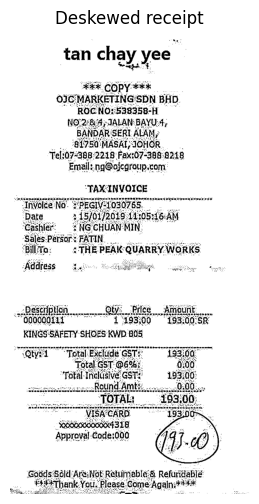

In [33]:
import numpy as np

def get_skew_angle(img):
    # Find edges
    edges = cv2.Canny(img, 50, 150, apertureSize=3)
    # Find lines using Hough transform
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 
                             threshold=100, 
                             minLineLength=100, 
                             maxLineGap=10)
    if lines is None:
        return 0.0
    angles = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
        angles.append(angle)
    return np.median(angles)

def deskew(img):
    angle = get_skew_angle(img)
    if abs(angle) < 1.0:  # skip if almost straight
        return img
    h, w = img.shape
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img, M, (w, h),
                              flags=cv2.INTER_CUBIC,
                              borderMode=cv2.BORDER_REPLICATE)
    return rotated

rec_deskewed = deskew(rec_adaptive)
show_image("Deskewed receipt", rec_deskewed, cmap='gray')

In [34]:
def preprocess_receipt(img_path, target_width=800):
    # 1. Load
    img = cv2.imread(img_path)
    
    # 2. Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 3. Resize to fixed width
    h, w = gray.shape
    scale = target_width / w
    gray = cv2.resize(gray, (target_width, int(h * scale)))
    
    # 4. CLAHE contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    
    # 5. Denoise
    denoised = cv2.GaussianBlur(enhanced, (3, 3), 0)
    
    # 6. Adaptive threshold
    thresh = cv2.adaptiveThreshold(
        denoised, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=11, C=2
    )
    
    # 7. Deskew
    final = deskew(thresh)
    
    return final

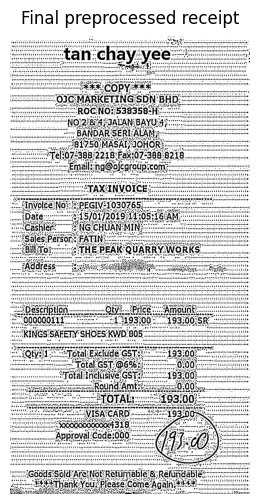

In [35]:
preprocessed = preprocess_receipt(rec_paths[0])
show_image("Final preprocessed receipt", preprocessed, cmap='gray')

In [36]:
import os

output_path = os.path.join(BASE_DIR, 'outputs', 'sample_preprocessed.png')
cv2.imwrite(output_path, preprocessed)
print("Saved to:", output_path)

Saved to: d:\HND NIBM\img processing & computer vision project\kyc-robustness\outputs\sample_preprocessed.png


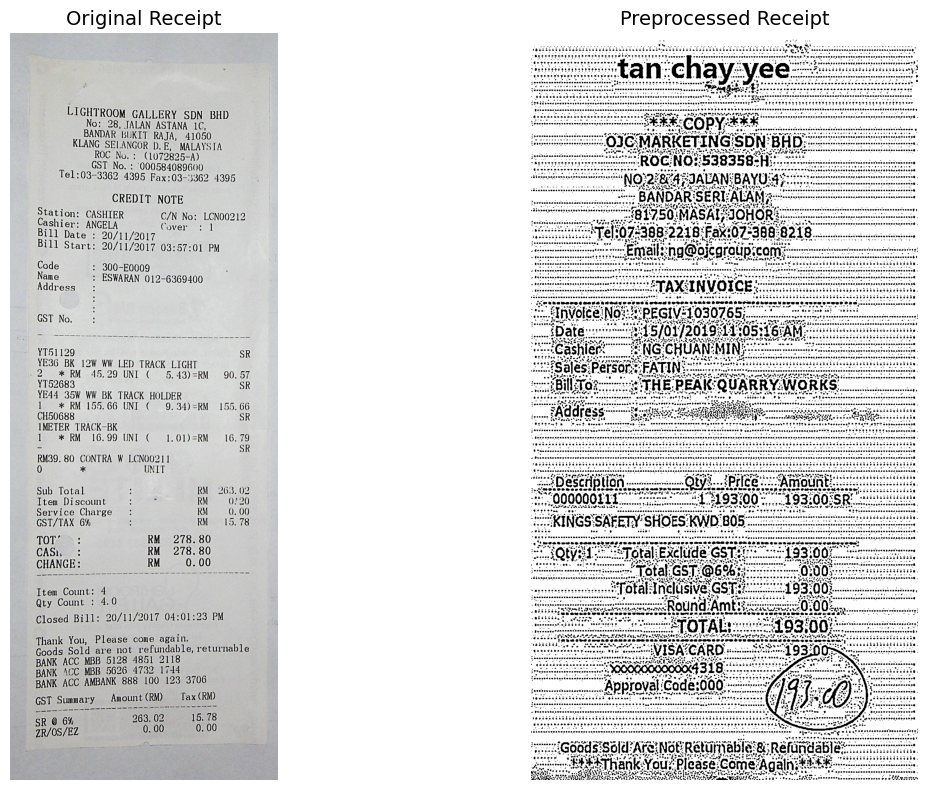

Comparison saved!


In [54]:
original = cv2.cvtColor(cv2.imread(rec_paths[12]), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].imshow(original)
axes[0].set_title("Original Receipt", fontsize=14)
axes[0].axis('off')

axes[1].imshow(preprocessed, cmap='gray')
axes[1].set_title("Preprocessed Receipt", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'before_after.png'), dpi=150)
plt.show()
print("Comparison saved!")

In [38]:
def show_image(title, img, cmap=None, size=(6, 6)):
    plt.figure(figsize=size)
    if cmap is None:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

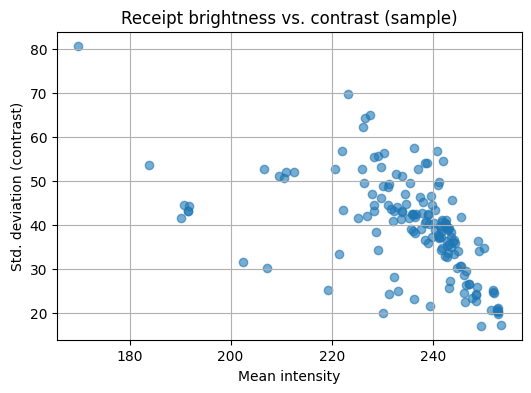

In [39]:
def image_stats(gray):
    mean = np.mean(gray)
    std = np.std(gray)
    return mean, std

means, stds = [], []

for path in rec_paths[:160]:  # sample subset
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    m, s = image_stats(gray)
    means.append(m)
    stds.append(s)

plt.figure(figsize=(6, 4))
plt.scatter(means, stds, alpha=0.6)
plt.xlabel("Mean intensity")
plt.ylabel("Std. deviation (contrast)")
plt.title("Receipt brightness vs. contrast (sample)")
plt.grid(True)
plt.show()

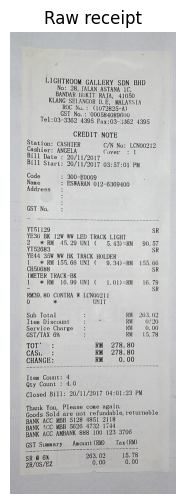

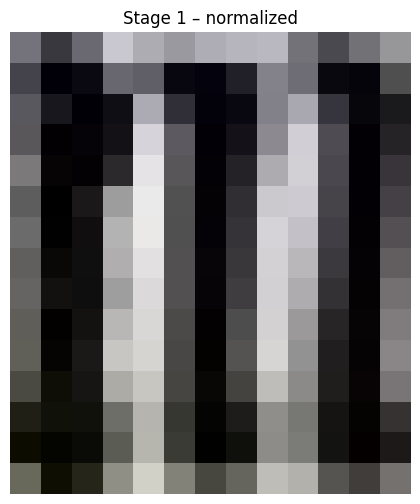

In [40]:
def find_receipt_contour(gray):
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    for c in contours:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)
        if len(approx) == 4:
            return approx
    return None

def order_points(pts):
    pts = pts.reshape(4, 2).astype("float32")
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)
    top_left = pts[np.argmin(s)]
    bottom_right = pts[np.argmax(s)]
    top_right = pts[np.argmin(diff)]
    bottom_left = pts[np.argmax(diff)]
    return np.array([top_left, top_right, bottom_right, bottom_left], dtype="float32")

def four_point_transform(image, pts):
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    width_top = np.linalg.norm(tr - tl)
    width_bottom = np.linalg.norm(br - bl)
    max_width = int(max(width_top, width_bottom))

    height_left = np.linalg.norm(bl - tl)
    height_right = np.linalg.norm(br - tr)
    max_height = int(max(height_left, height_right))

    dst = np.array([
        [0, 0],
        [max_width - 1, 0],
        [max_width - 1, max_height - 1],
        [0, max_height - 1]
    ], dtype="float32")

    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (max_width, max_height))
    return warped

def normalize_receipt(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    contour = find_receipt_contour(gray)
    if contour is None:
        return img  # fallback: return original
    warped = four_point_transform(img, contour)
    return warped

sample = cv2.imread(rec_paths[12])
norm = normalize_receipt(sample)
show_image("Raw receipt", sample)
show_image("Stage 1 – normalized", norm)

In [50]:
def preprocess_receipt(img_path, target_width=1200):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape
    scale = target_width / w
    gray = cv2.resize(gray, (target_width, int(h * scale)))

    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    thresh = cv2.adaptiveThreshold(
        enhanced, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31, 11
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel, iterations=1)

    return gray, enhanced, cleaned

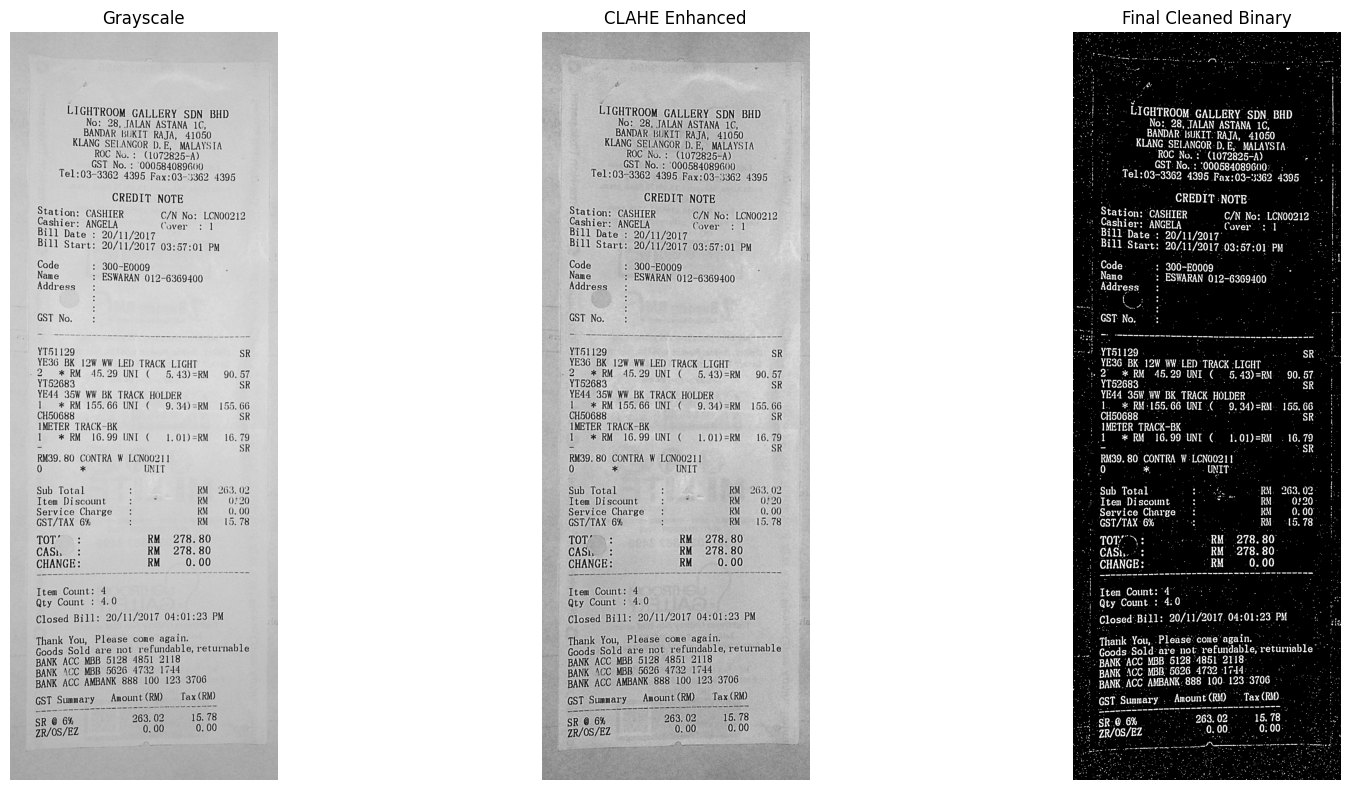

In [53]:
gray, enhanced, cleaned = preprocess_receipt(rec_paths[12])

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Grayscale")
axes[0].axis("off")

axes[1].imshow(enhanced, cmap="gray")
axes[1].set_title("CLAHE Enhanced")
axes[1].axis("off")

axes[2].imshow(cleaned, cmap="gray")
axes[2].set_title("Final Cleaned Binary")
axes[2].axis("off")

plt.tight_layout()
plt.show()

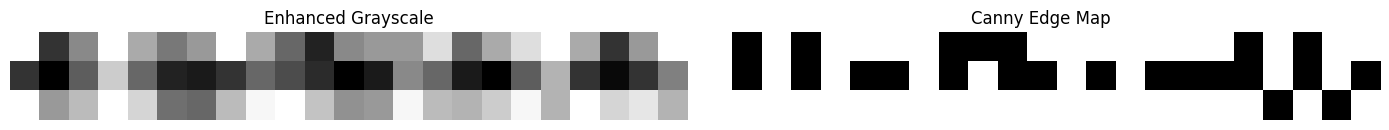

In [52]:
sample_path = rec_paths[0]
outputs = full_pipeline(sample_path)
edges = cv2.Canny(outputs["enhanced"], 50, 150)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

axes[0].imshow(outputs["enhanced"], cmap="gray")
axes[0].set_title("Enhanced Grayscale")
axes[0].axis("off")

axes[1].imshow(edges, cmap="gray")
axes[1].set_title("Canny Edge Map")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "figure_7_edge_map.png"), dpi=200, bbox_inches="tight")
plt.show()

In [55]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

REC_DIR = os.path.join(DATA_DIR, 'receipts_raw')
rec_paths = sorted(glob.glob(os.path.join(REC_DIR, "*")))
print("Total images:", len(rec_paths))

def safe_preprocess(img_path, target_width=800):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape
    scale = target_width / w
    gray = cv2.resize(gray, (target_width, int(h * scale)))

    blur = cv2.GaussianBlur(gray, (3, 3), 0)

    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    enhanced = clahe.apply(blur)

    binary = cv2.adaptiveThreshold(
        enhanced, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31, 11
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
    clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel, iterations=1)

    return gray, enhanced, clean

def entropy_img(gray):
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel()
    hist = hist / hist.sum()
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist))

def sharpness(gray):
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def black_ratio(binary_inv):
    return np.mean(binary_inv > 0)

rows = []

for path in rec_paths:
    try:
        gray, enhanced, clean = safe_preprocess(path)

        rows.append({
            "file": os.path.basename(path),

            "orig_mean": np.mean(gray),
            "orig_std": np.std(gray),
            "orig_entropy": entropy_img(gray),
            "orig_sharpness": sharpness(gray),

            "proc_mean": np.mean(enhanced),
            "proc_std": np.std(enhanced),
            "proc_entropy": entropy_img(enhanced),
            "proc_sharpness": sharpness(enhanced),

            "black_ratio": black_ratio(clean)
        })
    except Exception as e:
        print("Skipped:", path, str(e))

df = pd.DataFrame(rows)
print(df.shape)
df.head()

Total images: 163
(163, 10)


,file,orig_mean,orig_std,orig_entropy,orig_sharpness,proc_mean,proc_std,proc_entropy,proc_sharpness,black_ratio
0,000.jpg,240.432277,40.151825,3.795129,438.095314,235.295073,43.443183,4.270751,191.912003,0.095442
1,001.jpg,241.704959,38.116657,3.683003,409.349858,236.776014,41.452686,4.144736,180.067317,0.089959
2,002.jpg,250.136368,29.558292,0.520160,4590.968780,249.089988,25.743743,0.912386,409.241083,0.045448
3,003.jpg,228.573305,36.966851,5.973455,292.717540,210.534210,42.401373,6.795395,132.224397,0.111478
4,004.jpg,240.146510,38.840848,3.763880,345.702673,234.366760,43.229483,4.134544,155.511737,0.093088
